### Understanding Mahalanobis Distance;  A Beginner's Tutorial for Anomaly Detection--- This notebook teaches **one idea**: how Mahalanobis distance measures "unusualness" in data, and why it beats  Euclidean distance for anomaly detection. We'll use simple, made-up data so you can focus on the concept .

#### What you'll learn
#### 1. Why "distance from the mean" is a bad measure of unusualness when features are correlated
#### 2. How Mahalanobis distance fixes this — visually and mathematically
#### 3. How to compute it in Python with one line of code
#### 4. How to turn distance into a decision: "anomaly or not?"

#### **Prerequisites:** Basic Python, comfort with `numpy` and `matplotlib`.

## SetupRun this cell once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2
from scipy.spatial.distance import mahalanobis

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
np.random.seed(42)
print("Setup complete.")

Setup complete.


---## Step 1 — The Problem with Plain Distance. 
Imagine you collect two measurements from each person in a population:- **Height** (cm)- **Weight** (kg)These two features are **correlated** — taller people tend to weigh more. Let's generate 300 fake people.

In [2]:
# Generate 300 people with correlated height and weight
n = 300
height = np.random.normal(170, 10, n)              # mean 170 cm, std 10 cm
weight = 0.9 * (height - 170) + 70 + np.random.normal(0, 5, n)  # correlated + noise

# Mean of the population
mean = np.array([height.mean(), weight.mean()])

print(f"Average height: {mean[0]:.1f} cm")
print(f"Average weight: {mean[1]:.1f} kg")

Average height: 169.9 cm
Average weight: 69.8 kg


Now consider **two new people** who walk in:- **Person A:** Height = 170 cm, Weight = 90 kg (average height, heavy)- **Person B:** Height = 190 cm, Weight = 90 kg (tall, same weight as A)**Which one is more unusual?**Your gut probably says **Person A** — because 170 cm tall people usually don't weigh 90 kg, but 190 cm people often do.Let's see if plain "distance from average" agrees with our intuition.

In [13]:
# Two new people to evaluate
person_A = np.array([170, 90])
person_B = np.array([190, 90])

# Plain Euclidean distance from the population mean
euclidean_A = np.linalg.norm(person_A - mean)
euclidean_B = np.linalg.norm(person_B - mean)

print(f"Person A (170 cm, 90 kg): Euclidean distance from mean = {euclidean_A:.2f}")
print(f"Person B (190 cm, 90 kg): Euclidean distance from mean = {euclidean_B:.2f}")

Person A (170 cm, 90 kg): Euclidean distance from mean = 20.16
Person B (190 cm, 90 kg): Euclidean distance from mean = 28.43


**Surprised?** Plain distance gives **both people roughly the same score** — but our intuition says Person A is clearly more unusual.Why does Euclidean distance fail? Let's visualize.

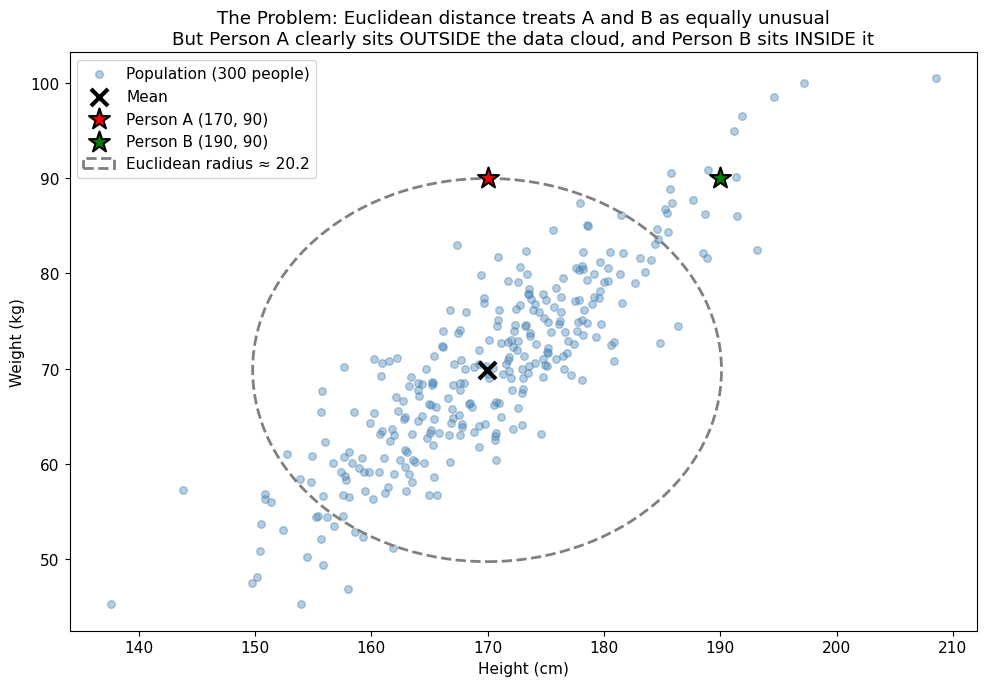

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the population
ax.scatter(height, weight, alpha=0.4, s=30, c="steelblue", label="Population (300 people)")

# Plot the mean
ax.scatter(*mean, c="black", marker="x", s=150, linewidth=3, label="Mean", zorder=5)

# Plot Person A and B
ax.scatter(*person_A, c="red", s=250, marker="*", edgecolor="black", linewidth=1.5,
           label="Person A (170, 90)", zorder=6)
ax.scatter(*person_B, c="green", s=250, marker="*", edgecolor="black", linewidth=1.5,
           label="Person B (190, 90)", zorder=6)

# Draw a circle = "all points equally far from mean in Euclidean sense"
circle = plt.Circle(mean, euclidean_A, fill=False, color="grey", linestyle="--", lw=2,
                    label=f"Euclidean radius ≈ {euclidean_A:.1f}")
ax.add_patch(circle)

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("The Problem: Euclidean distance treats A and B as equally unusual\nBut Person A clearly sits OUTSIDE the data cloud, and Person B sits INSIDE it")
ax.legend(loc="upper left")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

**👁 Look at the picture.** The dashed circle shows all points at Euclidean distance ≈ 21 from the mean. Both stars sit on this circle.But notice:- **Person B (green star)** sits *inside* the data cloud — it fits the trend- **Person A (red star)** sits *outside* the data cloud — it violates the trendThe Euclidean circle is the wrong shape. It treats every direction equally, but our data isn't shaped equally in every direction — it's stretched along a diagonal.**We need a distance measure that follows the shape of the data.**

---## Step 2 — The Idea Behind Mahalanobis DistanceMahalanobis distance asks a smarter question:> *"How many standard deviations away is this point, **after accounting for how the features co-vary**?"*It does three things automatically:1. **Centers** the data around its mean (subtract the mean)2. **Rotates** the coordinate system so correlated features become independent3. **Scales** so 1 unit = 1 standard deviation in every directionAfter these three steps, the oval cloud becomes a round cloud. Euclidean distance in this *transformed* space corresponds to **ellipses** in the original space — ellipses that follow the data's shape.Let's visualize.

In [15]:
# Compute the covariance matrix of our data
data = np.column_stack([height, weight])
cov_matrix = np.cov(data, rowvar=False)
print("Covariance matrix:")
print(cov_matrix.round(2))
print()
print("This 2x2 matrix captures:")
print(f"  • How height varies: variance = {cov_matrix[0,0]:.1f}")
print(f"  • How weight varies: variance = {cov_matrix[1,1]:.1f}")
print(f"  • How they CO-vary:  covariance = {cov_matrix[0,1]:.1f}  (positive = move together)")

Covariance matrix:
[[96.86 85.26]
 [85.26 98.13]]

This 2x2 matrix captures:
  • How height varies: variance = 96.9
  • How weight varies: variance = 98.1
  • How they CO-vary:  covariance = 85.3  (positive = move together)


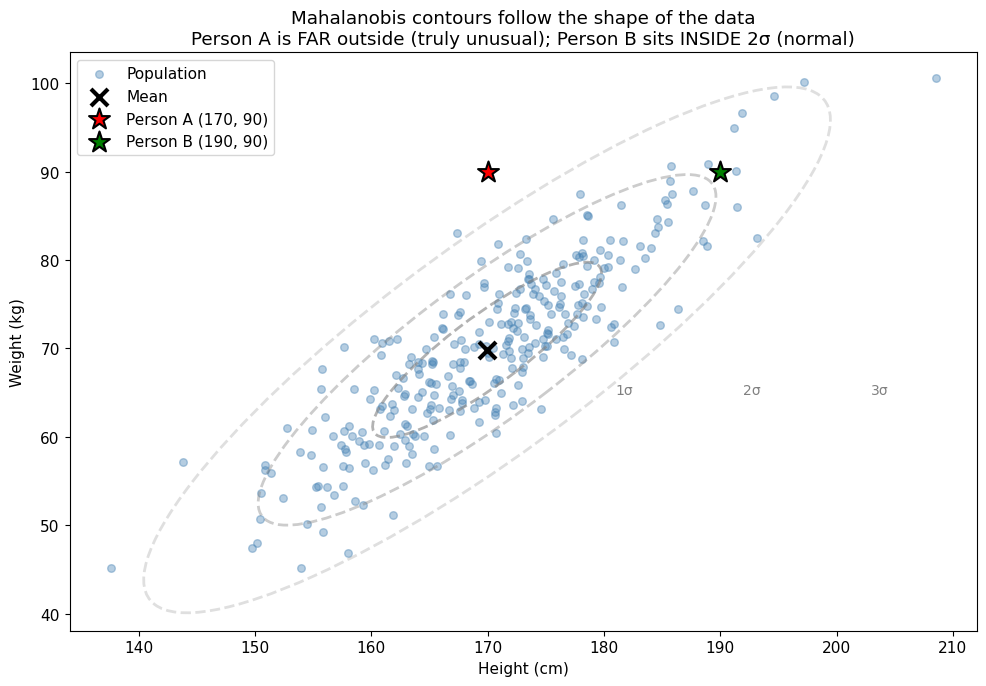

In [16]:
# Helper to draw Mahalanobis distance contours (ellipses)
def draw_ellipse(ax, mean, cov, n_std, **kwargs):
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (plt.matplotlib.transforms.Affine2D()
              .rotate_deg(45).scale(scale_x, scale_y).translate(mean[0], mean[1]))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(height, weight, alpha=0.4, s=30, c="steelblue", label="Population")

# Draw Mahalanobis contours at 1, 2, 3 standard deviations
for n_std, alpha in [(1, 0.6), (2, 0.4), (3, 0.25)]:
    draw_ellipse(ax, mean, cov_matrix, n_std,
                 facecolor="none", edgecolor="grey", linestyle="--", lw=2, alpha=alpha)
    ax.text(mean[0] + 11*n_std, mean[1] - 5, f"{n_std}σ", color="grey", fontsize=10)

ax.scatter(*mean, c="black", marker="x", s=150, linewidth=3, label="Mean", zorder=5)
ax.scatter(*person_A, c="red", s=250, marker="*", edgecolor="black", linewidth=1.5,
           label="Person A (170, 90)", zorder=6)
ax.scatter(*person_B, c="green", s=250, marker="*", edgecolor="black", linewidth=1.5,
           label="Person B (190, 90)", zorder=6)

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Mahalanobis contours follow the shape of the data\nPerson A is FAR outside (truly unusual); Person B sits INSIDE 2σ (normal)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**The dashed ellipses are Mahalanobis "circles"** — they all contain points at the same Mahalanobis distance from the mean. They follow the data's natural tilt.- **Person B (green)** sits comfortably inside the 2σ ellipse — completely normal-  **Person A (red)**  sits *well outside* the 3σ ellipse — genuinely unusualThis matches our intuition perfectly.

---## Step 3 — The Formula (Easier Than It Looks)$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \, \boldsymbol{\Sigma}^{-1} \, (\mathbf{x} - \boldsymbol{\mu})} $$ In plain words:| $\mathbf{x}$ | The point you're testing || $\boldsymbol{\mu}$ | The mean of your data || $\boldsymbol{\Sigma}$ | The covariance matrix || $\boldsymbol{\Sigma}^{-1}$ | The inverse of the covariance matrix || $D_M$ | The Mahalanobis distance |It's literally a generalization of "z-score" (how many standard deviations away) to multiple correlated dimensions.Let's compute it for our two people.

In [17]:
# Compute Mahalanobis distance manually — see exactly what the formula does
cov_inverse = np.linalg.inv(cov_matrix)

def mahalanobis_distance(point, mean, cov_inv):
    diff = point - mean              # Step 1: subtract mean
    return np.sqrt(diff @ cov_inv @ diff)  # Steps 2 & 3 baked into the matrix inverse

maha_A = mahalanobis_distance(person_A, mean, cov_inverse)
maha_B = mahalanobis_distance(person_B, mean, cov_inverse)

print("=" * 55)
print("Comparing the two distance measures")
print("=" * 55)
print(f"\n{'Person':<12} {'Euclidean':>12} {'Mahalanobis':>14}")
print("-" * 40)
print(f"{'A (170, 90)':<12} {euclidean_A:>12.2f} {maha_A:>14.2f}")
print(f"{'B (190, 90)':<12} {euclidean_B:>12.2f} {maha_B:>14.2f}")
print()
print("Conclusion:")
print(f"  • Euclidean says A and B are similarly unusual")
print(f"  • Mahalanobis says A is {maha_A/maha_B:.1f}x more unusual than B  ✓")

Comparing the two distance measures

Person          Euclidean    Mahalanobis
----------------------------------------
A (170, 90)         20.16           4.19
B (190, 90)         28.43           2.10

Conclusion:
  • Euclidean says A and B are similarly unusual
  • Mahalanobis says A is 2.0x more unusual than B  ✓


You can also use `scipy.spatial.distance.mahalanobis` — same answer, one line.

In [18]:
# scipy version (same result)
maha_A_scipy = mahalanobis(person_A, mean, cov_inverse)
maha_B_scipy = mahalanobis(person_B, mean, cov_inverse)
print(f"Person A: {maha_A_scipy:.2f}  (scipy)")
print(f"Person B: {maha_B_scipy:.2f}  (scipy)")

Person A: 4.19  (scipy)
Person B: 2.10  (scipy)


---## Step 4 — Turning Distance Into a DecisionA number on its own isn't useful. We need a **threshold**: above this, flag as anomaly. Below it, treat as normal.**The principled rule:** if your data is roughly Gaussian, the squared Mahalanobis distance follows a chi-squared distribution with degrees of freedom equal to the number of features. So:> Threshold = √(chi-squared inverse CDF at 1−α, df=p)where α is the false-positive rate you accept (e.g., 0.01 = "1% of normal data may get flagged").

In [9]:
n_features = 2

print("Chi-squared thresholds for 2-feature data:")
print(f"{'Significance α':>16} {'Threshold':>12} {'Meaning':>30}")
print("-" * 65)
for alpha in [0.10, 0.05, 0.01, 0.001]:
    threshold = np.sqrt(chi2.ppf(1 - alpha, df=n_features))
    print(f"{alpha:>16.3f} {threshold:>12.2f}  "
          f"flag the {alpha*100:>4.1f}% most extreme points")

print()
print(f"Our two people:")
print(f"  Person A: Mahalanobis = {maha_A:.2f}")
print(f"  Person B: Mahalanobis = {maha_B:.2f}")
print()
print(f"At α=0.01 (threshold = {np.sqrt(chi2.ppf(0.99, df=2)):.2f}):")
print(f"  • Person A is {'FLAGGED as anomaly' if maha_A > np.sqrt(chi2.ppf(0.99, df=2)) else 'NORMAL'}")
print(f"  • Person B is {'FLAGGED as anomaly' if maha_B > np.sqrt(chi2.ppf(0.99, df=2)) else 'NORMAL'}")

Chi-squared thresholds for 2-feature data:
  Significance α    Threshold                        Meaning
-----------------------------------------------------------------
           0.100         2.15  flag the 10.0% most extreme points
           0.050         2.45  flag the  5.0% most extreme points
           0.010         3.03  flag the  1.0% most extreme points
           0.001         3.72  flag the  0.1% most extreme points

Our two people:
  Person A: Mahalanobis = 4.19
  Person B: Mahalanobis = 2.10

At α=0.01 (threshold = 3.03):
  • Person A is FLAGGED as anomaly
  • Person B is NORMAL


---## Step 5 — A Complete Anomaly Detection ExampleLet's score the entire population plus a few injected anomalies, and visualize the result.

In [10]:
# Create some test points — most are normal, a few are anomalies
test_points = np.array([
    [170, 70],   # normal
    [180, 78],   # normal
    [160, 60],   # normal
    [170, 90],   # anomaly (our Person A)
    [150, 85],   # anomaly (short and heavy)
    [195, 65],   # anomaly (tall and light)
    [185, 85],   # normal (fits trend)
])
test_labels = ["normal", "normal", "normal", "anomaly", "anomaly", "anomaly", "normal"]

# Score each test point
threshold = np.sqrt(chi2.ppf(0.99, df=2))  # α = 0.01
print(f"Decision threshold: {threshold:.2f}\n")
print(f"{'Point':<15} {'Mahalanobis':>12} {'Decision':>14} {'Truth':>10}")
print("-" * 55)
for point, truth in zip(test_points, test_labels):
    d = mahalanobis_distance(point, mean, cov_inverse)
    decision = "ANOMALY" if d > threshold else "normal"
    correct = "✓" if (decision.lower() == truth) else "✗"
    print(f"({point[0]}, {point[1]})  {d:>12.2f} {decision:>14} {truth:>10}   {correct}")

Decision threshold: 3.03

Point            Mahalanobis       Decision      Truth
-------------------------------------------------------
(170, 70)          0.02         normal     normal   ✓
(180, 78)          1.03         normal     normal   ✓
(160, 60)          1.04         normal     normal   ✓
(170, 90)          4.19        ANOMALY    anomaly   ✓
(150, 85)          7.10        ANOMALY    anomaly   ✓
(195, 65)          6.15        ANOMALY    anomaly   ✓
(185, 85)          1.58         normal     normal   ✓


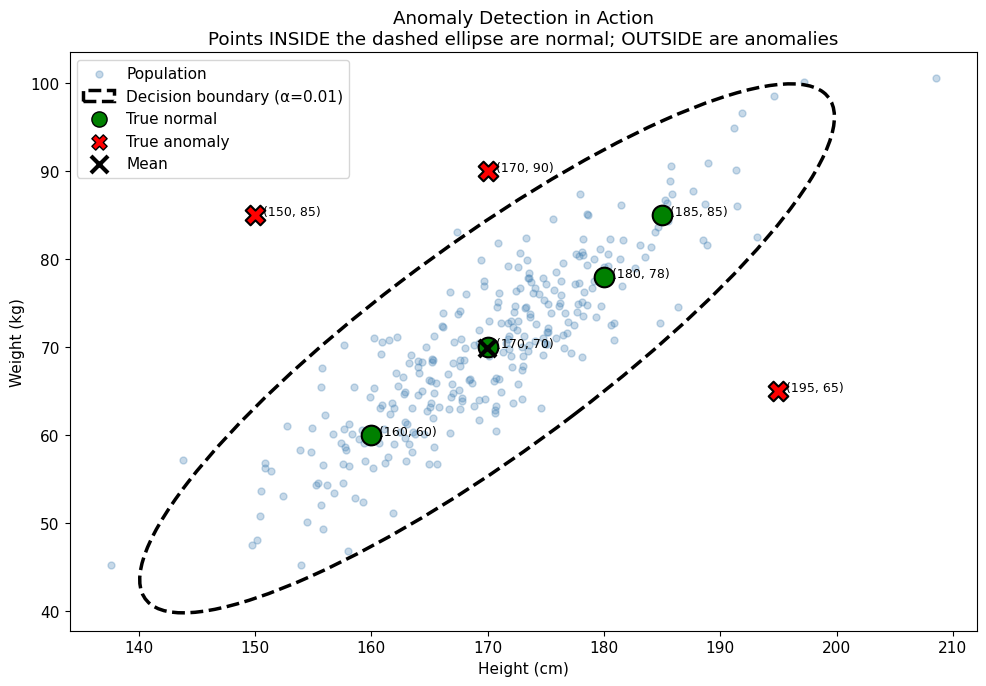

In [19]:
# Visualize the decision boundary
fig, ax = plt.subplots(figsize=(10, 7))

# Population
ax.scatter(height, weight, alpha=0.3, s=25, c="steelblue", label="Population")

# Mahalanobis decision boundary (the threshold ellipse)
draw_ellipse(ax, mean, cov_matrix, threshold,
             facecolor="none", edgecolor="black", linestyle="--", lw=2.5,
             label=f"Decision boundary (α=0.01)")

# Test points colored by truth
for point, truth in zip(test_points, test_labels):
    color = "red" if truth == "anomaly" else "green"
    marker = "X" if truth == "anomaly" else "o"
    ax.scatter(*point, c=color, s=200, marker=marker, edgecolor="black", linewidth=1.5, zorder=5)
    ax.annotate(f"  ({point[0]}, {point[1]})", xy=point, fontsize=9)

ax.scatter([], [], c="green", s=120, marker="o", edgecolor="black", label="True normal")
ax.scatter([], [], c="red", s=120, marker="X", edgecolor="black", label="True anomaly")
ax.scatter(*mean, c="black", marker="x", s=150, linewidth=3, label="Mean", zorder=5)

ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight (kg)")
ax.set_title("Anomaly Detection in Action\nPoints INSIDE the dashed ellipse are normal; OUTSIDE are anomalies")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Read the picture.** The dashed ellipse is your decision boundary:- Points **inside** → classified as normal (green circles)- Points **outside** → classified as anomalies (red X marks)The ellipse tilts with the data. A tall, light person (195, 65) gets flagged even though their height is "normal" — because their weight doesn't match their height.

## Summary — What to Remember
### Key intuitions
#### 1. **Mahalanobis distance respects the shape of your data. ** Euclidean treats every direction equally. Mahalanobis tilts and scales according to how your features co-vary. 2. **It's just a generalized z-score.** A z-score tells you how many standard deviations one value is from the mean. Mahalanobis distance does the same in multiple correlated dimensions. 3. **The chi-squared threshold is principled.  For Gaussian data, the chi-squared rule gives you a defensible threshold tied to a false-positive rate. 

#### Limitations to remember- **Assumes one cluster.** If your data has multiple modes (e.g., two distinct subpopulations), Mahalanobis distance will misbehave.- **Sensitive to outliers in training.  ** If your "normal" data is already contaminated, the covariance matrix gets corrupted. Use `sklearn.covariance.MinCovDet` for a robust version.- **Assumes roughly Gaussian features.** Heavy-tailed or skewed features will produce more false alarms than the chi-squared rule predicts.### Where to go next- Apply this to a real dataset of your choice — anything with 2-10 numeric features- Try `sklearn.covariance.MinCovDet` for outlier-robust covariance estimation- Compare with `sklearn.ensemble.IsolationForest` to see when each method shines---### ReferenceMahalanobis, P.C. (1936). "On the generalised distance in statistics." *Proceedings of the National Institute of Sciences of India* 2(1): 49–55.*The original paper, by the founder of the Indian Statistical Institute.*